## Обучение с учителем. Задача классификации

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.combine import SMOTEENN

### Чтение данных

In [2]:
data = pd.read_csv(f"../data/credit_card_fraud_filtered.csv")

data.head(5)

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud,high_price_anomaly
0,57.877857,0.311140,1.945940,1,1,0,0,0,0
1,10.829943,0.175592,1.294219,1,0,0,0,0,0
2,5.091079,0.805153,0.427715,1,0,0,1,0,0
3,2.247564,5.600044,0.362663,1,1,0,1,0,0
4,44.190936,0.566486,2.222767,1,1,0,1,0,0


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 884794 entries, 0 to 884793
Data columns (total 9 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   distance_from_home              884794 non-null  float64
 1   distance_from_last_transaction  884794 non-null  float64
 2   ratio_to_median_purchase_price  884794 non-null  float64
 3   repeat_retailer                 884794 non-null  int64  
 4   used_chip                       884794 non-null  int64  
 5   used_pin_number                 884794 non-null  int64  
 6   online_order                    884794 non-null  int64  
 7   fraud                           884794 non-null  int64  
 8   high_price_anomaly              884794 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 60.8 MB


### Выделение целевого признака и предикторов

In [3]:
y = data['fraud']
x = data.drop('fraud', axis=1)

#### Разбиение на обучающую и тестовую выборки с использованием стратификации

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.15, 
    random_state=81, 
    stratify=y
)

In [5]:
x_train[:5]

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,high_price_anomaly
189042,52.252629,0.061874,0.705385,1,0,0,0,0
361532,2.903823,0.169253,0.538185,1,1,0,0,0
38365,39.065192,2.259835,2.276197,1,0,0,0,0
349705,11.520815,0.300404,0.534076,1,1,0,0,0
665313,120.382848,6.409485,0.337039,1,1,1,1,0


In [6]:
y_train[:5]

189042    0
361532    0
38365     0
349705    0
665313    0
Name: fraud, dtype: int64

In [7]:
y.value_counts()

fraud
0    828124
1     56670
Name: count, dtype: int64

Рассматриваем задачу бинарной классификации, так как целевой признак `fraud` принимает значения 0 или 1.

### Масштабирование данных

In [17]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

### Дисбаланс классов
#### Визуализация

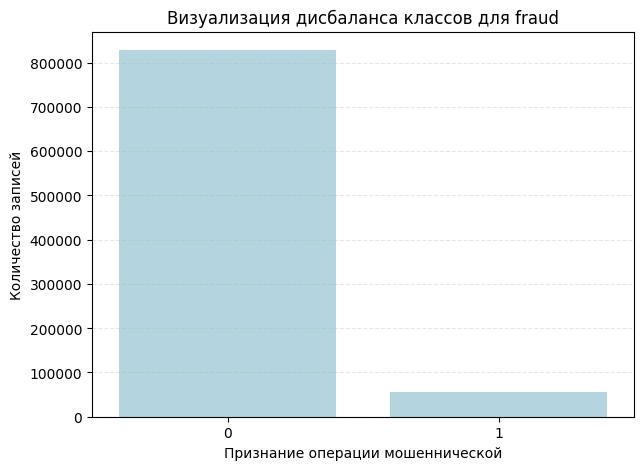

In [18]:
plt.figure(figsize=(7, 5))

sns.countplot(data, x='fraud', color='lightblue')

plt.title("Визуализация дисбаланса классов для fraud")
plt.xlabel("Признание операции мошеннической")
plt.ylabel("Количество записей")
plt.grid(axis='y', linestyle='--', alpha=0.3)

#### Балансировка классов при помощи метода `SMOTEENN`

Данный метод основан на `SMOTE`, который создает синтетические данные, однако также использует `ENN` (редактирование ближайших соседей). `SMOTE` находит близкие объекты миноритарного класса в пространстве признаков и создает между ними "синтетические" новые точки. Edited Nearest Neighbors берет каждую точку и смотрит на её k ближайших соседей (обычно 3). Если большинство соседей принадлежат к другому классу, точка удаляется. 

Альтернативным вариантом было использование метода `SMOTETomek`, который находит и удаляет «связи Томека» (пары близкорасположенных объектов разных классов). Однако для данной задачи был выбран более агрессивный метод `SMOTEENN`, так как он позволяет провести более жесткую очистку границ между классами, что способствует повышению точности классификации в условиях зашумленности данных.

Text(0.5, 1.0, 'Визуализация признаков distance_from_home и ratio_to_median_purchase_price')

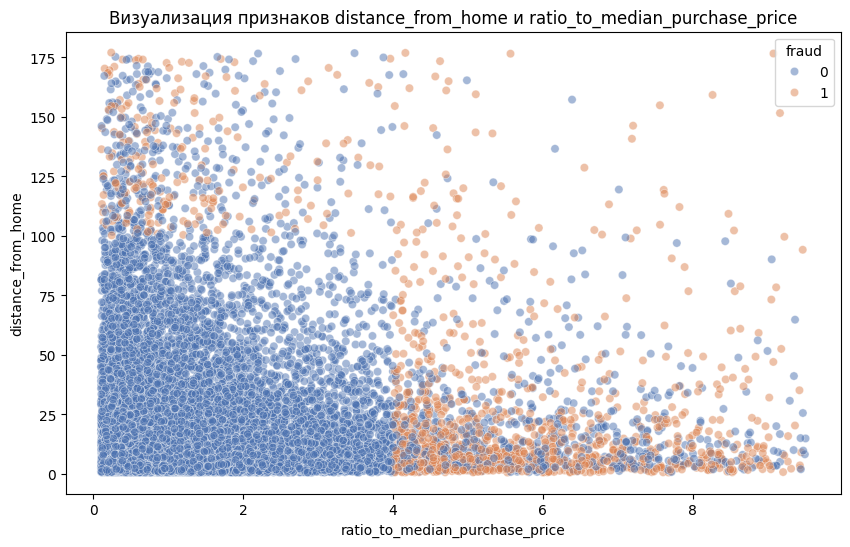

In [20]:
data_sample = data.sample(20_000, random_state=81)


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data_sample,
    x='ratio_to_median_purchase_price',
    y='distance_from_home',
    hue='fraud',
    palette='deep',
    alpha=0.5
)

plt.title('Визуализация признаков distance_from_home и ratio_to_median_purchase_price')

Визуализация признаков `distance_from_home` и `ratio_to_median_purchase_price` показала значительное перекрытие классов (overlap), что тоже способствует выбору `SMOTEENN`

In [ ]:
sme = SMOTEENN(random_state=81)
x_train_res, y_train_res = sme.fit_resample(x_train_scaled, y_train)